# L1.14 — CNS: communication

**Level 1 · Core · 60 minutes**

**Goal.** You can delay, lose, and space out the messages between aircraft.

**Check at the end.** You can say why a reception probability of 0.9 does not give an update
interval of 1.11 s.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. The C of CNS

Navigation makes a `Message`. Communication decides **whether** it arrives and **when**.

```python
class CommunicationModel:
    def step(state, broadcasts, receivers, t, rng) -> CommState: ...
```

`CommState` holds two things:

| Field | What it holds |
| --- | --- |
| `held` | The last message each receiver **has**, keyed by the directed pair `(source, receiver)`. |
| `in_flight` | Messages that were accepted onto the air and have not arrived yet. |

Every link is **directed**. `A -> B` and `B -> A` are two separate links with their own reception
draw and their own delay. A can hear B while B cannot hear A. That asymmetry is the point of the
whole layer.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN, ORANGE = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c", "#ff7f0e"

from opencdarr import M600, create_aircraft, generator, root_seed_sequence
from opencdarr.cns import (
    BroadcastSchedule,
    Comm,
    GnssNavigation,
    constant_latency,
    lognormal_latency,
    random_broadcast_phase,
    uniform_latency,
)

FLEET = [create_aircraft(M600, id=name, lat=52.0 + 0.01 * k, lon=4.0, trk=0.0, gs=10.0,
                         pos_ci95=10.0, vel_ci95=1.0)
         for k, name in enumerate(("OWN", "INT"))]
NAV = GnssNavigation()


def stream(seed: int):
    return generator(root_seed_sequence(seed))


perfect = Comm()
state = perfect.initial_state()
msgs = [NAV.measure(NAV.initial_state(), ac, 0.0, stream(k)) for k, ac in enumerate(FLEET)]
state = perfect.step(state, msgs, FLEET, t=0.0, rng=stream(9))

print("with a perfect link, after one tick:")
for (source, receiver), held in state.held.items():
    print(f"    {source} -> {receiver}:  measured at t = {held.t_meas:.1f} s")
print(f"    still in flight: {len(state.in_flight)}")

with a perfect link, after one tick:
    INT -> OWN:  measured at t = 0.0 s
    OWN -> INT:  measured at t = 0.0 s
    still in flight: 0


## 2. Lose messages

`reception_prob` is the probability that a broadcast reaches a receiver. Give it a scalar for the
whole fleet, or a mapping keyed by the **directed** pair.

```python
Comm(reception_prob=0.9)                                  # every link
Comm(reception_prob={("OWN", "INT"): 0.9,                 # OWN's broadcasts reach INT 90 % of the time
                     ("INT", "OWN"): 0.5})                # INT's reach OWN only half the time
```

A pair you leave out of the mapping defaults to 1.0. A link naming an aircraft that is not in the
fleet is rejected, not ignored — a typo in an id would otherwise give you a perfect link and no
warning.

In [2]:
def broadcast_run(comm, n_seconds: float = 400.0, dt: float = 0.25, tx_interval: float = 1.0,
                  seed: int = 3):
    """Transmit every `tx_interval`, sample every `dt`. Returns the age OWN holds for INT.

    `dt` is finer than `tx_interval` on purpose: a sub-second delay is invisible if you only look
    once a second.
    """
    comm_state = comm.initial_state()
    nav_stream, comm_stream = stream(seed), stream(seed + 100)
    ages = []
    for k in range(int(n_seconds / dt)):
        t = k * dt
        due = abs(t / tx_interval - round(t / tx_interval)) < 1e-9
        msgs = [NAV.measure(NAV.initial_state(), ac, t, nav_stream) for ac in FLEET] if due else []
        comm_state = comm.step(comm_state, msgs, FLEET, t, comm_stream)
        held = comm_state.held.get(("INT", "OWN"))
        ages.append(np.nan if held is None else t - held.t_meas)
    return np.array(ages)


print(f"{'reception_prob':>16}{'delivered':>12}{'mean age':>11}{'mean gap':>11}{'worst gap':>12}")
for p in (1.0, 0.9, 0.7, 0.4):
    ages = broadcast_run(Comm(reception_prob=p), dt=1.0)
    fresh = ages == 0.0                       # a tick where a brand-new message arrived
    gaps = np.diff(np.flatnonzero(fresh))
    print(f"{p:>16.1f}{fresh.mean():>12.3f}{np.nanmean(ages):>11.2f}{gaps.mean():>11.2f}"
          f"{gaps.max():>12.0f}")

  reception_prob   delivered   mean age   mean gap   worst gap
             1.0       1.000       0.00       1.00           1
             0.9       0.882       0.14       1.13           4
             0.7       0.698       0.45       1.43           6
             0.4       0.410       1.54       2.44          12


Read the `0.9` row. Nine broadcasts in ten arrive, so a first guess says the gap between updates is
$1/0.9 = 1.11$ s. The measured mean gap is larger than that, and the worst gap is far larger.

The reason is that losses **compound**. The number of ticks until the next success is geometric, so
the gap is 1 tick with probability 0.9, 2 with 0.09, 3 with 0.009, and so on. The mean of that is
indeed $1/p$ ticks — but the aircraft does not fly the mean. It flies the **tail**, and the tail is
where a resolver works from a stale position for four or five seconds together.

Always report the worst gap beside the mean.

## 3. Delay messages

`latency` is how long a message takes to arrive. Give it a number for a fixed delay, or one of three
distributions:

| Constructor | Shape | Use it for |
| --- | --- | --- |
| `constant_latency(s)` | One value. Draws nothing. | A baseline. |
| `uniform_latency(low, high)` | Flat. | Simple jitter. |
| `lognormal_latency(median, sigma)` | Positive, right-skewed. | The usual first-order datalink model. |

`lognormal_latency` takes the **median**, not the mean, because `exp(mu)` is the median of a
lognormal and that makes the typical delay directly readable.

In [3]:
LATENCIES = {
    "none": 0.0,
    "constant 0.5 s": constant_latency(0.5),
    "uniform 0.1-1.5 s": uniform_latency(0.1, 1.5),
    "lognormal med 0.5, sigma 0.4": lognormal_latency(median=0.5, sigma=0.4),
    "lognormal med 0.5, sigma 1.0": lognormal_latency(median=0.5, sigma=1.0),
}

print(f"{'latency':<32}{'mean age':>11}{'median age':>13}{'99th pct':>11}")
age_samples = {}
for label, latency in LATENCIES.items():
    ages = broadcast_run(Comm(latency=latency))
    age_samples[label] = ages
    print(f"{label:<32}{np.nanmean(ages):>11.3f}{np.nanmedian(ages):>13.3f}"
          f"{np.nanpercentile(ages, 99):>11.3f}")

latency                            mean age   median age   99th pct
none                                  0.375        0.375      0.750
constant 0.5 s                        0.875        0.750      1.250
uniform 0.1-1.5 s                     1.286        1.250      2.250
lognormal med 0.5, sigma 0.4          1.052        1.000      2.000
lognormal med 0.5, sigma 1.0          1.169        1.000      2.750


## 4. Space the transmissions out

`BroadcastSchedule` owns the timing. It is separate from `Comm` because *when* an aircraft
transmits and *whether* the transmission arrives are two different questions.

```python
BroadcastSchedule(interval=1.0, phase=None, jitter=0.0)
BroadcastSchedule.at_rate(2.0)          # the same thing, written in Hz
```

| Field | What it does |
| --- | --- |
| `interval` | The nominal period. 1 s is the reference ADS-L rate. |
| `phase` | Each aircraft's start offset. `None` aligns them all at `t = 0`. |
| `jitter` | Dithers each gap by `U(-jitter, +jitter)`. It needs its own generator, and it must be smaller than `interval`. |

Four methods drive it: `initial(n)` builds the clocks, `due(clock, t)` says who transmits now,
`advance(clock_i, rng)` moves one clock on, and `random_broadcast_phase(n, interval, rng)` draws a
set of offsets.

Aligned phase is the **pessimally correlated** case: every aircraft transmits at the same instant,
so every aircraft's picture goes stale at the same instant. Random phase spreads that out.

In [4]:
def transmit_times(schedule, n_aircraft: int, t_max: float = 12.0, seed: int = 4):
    """When each aircraft transmits, using the schedule's own clock API."""
    clocks = schedule.initial(n_aircraft)
    rng = stream(seed)
    times = [[] for _ in range(n_aircraft)]
    t = 0.0
    while t <= t_max:
        for i in schedule.due(clocks, t):
            times[i].append(t)
            clocks[i] = schedule.advance(clocks[i], rng)
        t = round(t + 0.05, 4)
    return times


N = 4
SCHEDULES = {
    "interval 1 s, aligned": BroadcastSchedule(interval=1.0),
    "interval 2 s, aligned": BroadcastSchedule(interval=2.0),
    "at_rate(2 Hz)": BroadcastSchedule.at_rate(2.0),
    "interval 1 s, random phase": BroadcastSchedule(
        interval=1.0, phase=random_broadcast_phase(N, 1.0, stream(7))),
    "interval 1 s, jitter 0.4 s": BroadcastSchedule(interval=1.0, jitter=0.4),
}

for label, sched in SCHEDULES.items():
    times = transmit_times(sched, N)
    gaps = np.diff(times[0])
    print(f"{label:<30} first gaps {np.round(gaps[:4], 2)}   mean {gaps.mean():.2f} s")

interval 1 s, aligned          first gaps [1. 1. 1. 1.]   mean 1.00 s
interval 2 s, aligned          first gaps [2. 2. 2. 2.]   mean 2.00 s
at_rate(2 Hz)                  first gaps [0.5 0.5 0.5 0.5]   mean 0.50 s
interval 1 s, random phase     first gaps [1. 1. 1. 1.]   mean 1.00 s
interval 1 s, jitter 0.4 s     first gaps [1.4 1.2 1.  0.9]   mean 1.07 s


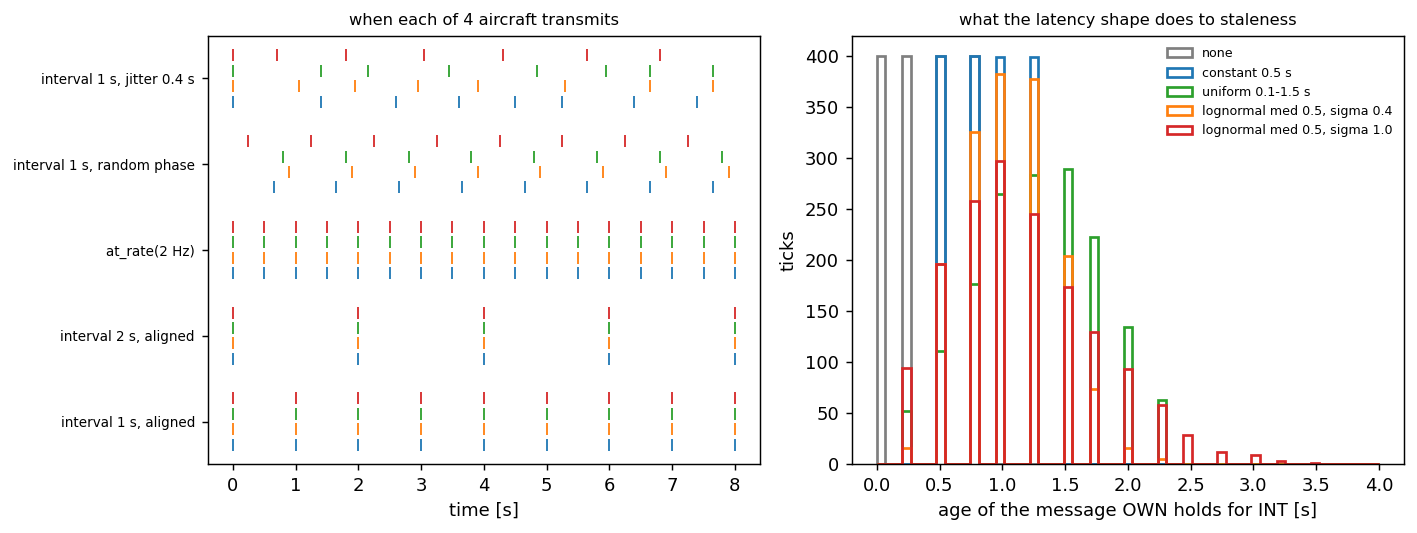

In [5]:
fig, (ax_s, ax_a) = plt.subplots(1, 2, figsize=(11.0, 4.2))

offset = 0
labels, ticks = [], []
for label, sched in SCHEDULES.items():
    times = transmit_times(sched, N, t_max=8.0)
    for i, ts in enumerate(times):
        ax_s.plot(ts, [offset + i * 0.18] * len(ts), ls="none", marker="|", ms=7,
                  color=(BLUE, ORANGE, GREEN, RED)[i])
    labels.append(label)
    ticks.append(offset + 0.27)
    offset += 1.0
ax_s.set_yticks(ticks)
ax_s.set_yticklabels(labels, fontsize=7.5)
ax_s.set_xlabel("time [s]")
ax_s.set_title(f"when each of {N} aircraft transmits", fontsize=9)

for (label, ages), colour in zip(age_samples.items(), (GREY, BLUE, GREEN, ORANGE, RED)):
    finite = ages[np.isfinite(ages)]
    ax_a.hist(finite, bins=np.linspace(0, 4, 60), histtype="step", lw=1.5, color=colour,
              label=label)
ax_a.set_xlabel("age of the message OWN holds for INT [s]")
ax_a.set_ylabel("ticks")
ax_a.set_title("what the latency shape does to staleness", fontsize=9)
ax_a.legend(frameon=False, fontsize=7)
fig.tight_layout()

## 5. Put loss and delay together

The two compound. A lost message means the receiver keeps an older one, and a delayed message means
even the newest one describes the past.

The quantity that matters downstream is the **age** of what the separation logic reads. Lesson L1.16
gives you the function that reports it.

In [6]:
print(f"{'reception':>10}  {'latency':<30}{'mean age':>10}{'99th pct':>10}{'worst':>8}")
for p in (1.0, 0.8):
    for label, latency in (("none", 0.0),
                           ("lognormal 0.5 s, sigma 0.8", lognormal_latency(0.5, 0.8))):
        ages = broadcast_run(Comm(reception_prob=p, latency=latency))
        print(f"{p:>10.1f}  {label:<30}{np.nanmean(ages):>10.2f}"
              f"{np.nanpercentile(ages, 99):>10.2f}{np.nanmax(ages):>8.2f}")

 reception  latency                         mean age  99th pct   worst
       1.0  none                                0.38      0.75    0.75
       1.0  lognormal 0.5 s, sigma 0.8          1.14      2.50    3.50
       0.8  none                                0.64      2.75    3.75
       0.8  lognormal 0.5 s, sigma 0.8          1.35      3.50    4.25


## Do it yourself

1. Build a `Comm` with an asymmetric mapping: `{("OWN", "INT"): 0.95, ("INT", "OWN"): 0.5}`. Check
   that only one direction degrades.
2. Name an aircraft that is not in the fleet in that mapping. Read the error.
3. Build `BroadcastSchedule(interval=1.0, jitter=1.0)`. Read the error, and say why the rule exists.
4. Set `interval=4.0` and repeat section 2. Compare the worst gap.

## Check

1. Why does a reception probability of 0.9 not give an update interval of 1.11 s?
2. Why are `BroadcastSchedule` and `Comm` separate objects?
3. Aligned phase is called the pessimally correlated case. Why?

## Next

`L1.15 — Link gates`. Loss and delay are statistical. Next you switch a link off for a physical
reason.